# Does a drug's ΔE double range track how fast resistance to it develops?

One point per drug, both axes numbers.

**x — the drug's ΔE double range.** Each top-ddE DRM pair in `ms0_5/{protein}/data/top_20_DRM.txt`
has a ΔE double computed on every sequence in that protein's alignment; its **range** is the 95th
minus the 5th percentile of that distribution, in the model's energy units — how much the
background a mutation lands in moves the energetic cost of acquiring the pair. A pair is
attributed to a drug when the drug's IAS-USA position list contains at least one of the pair's two
positions, and the drug's x is the **median** over its pairs (pair-to-pair IQR drawn as a bar).

**y — average time to the first resistance mutation, in weeks of cell-culture selection**, read
from `drug_resistance_time_literature.csv` next to this notebook. 14 of the 24 drugs have a value;
the other ten are blank and marked `FILL IN`.

**The y axis is pooled across four different selection studies and that is its main weakness.**
Passage protocol, cell type, virus (patient-derived isolate vs laboratory strain), drug
concentration schedule and how often the cultures were genotyped all differ between them, so a
two-fold difference in weeks between two drugs from different studies is not necessarily real.
The sources are carried per drug in the `source` and `confidence` columns and printed in the
table below. Within one study the comparison is sound; across studies, read the figure as a rank
ordering at best.

`barrier_mutations` — minimum DRMs for high-level resistance, IAS-USA 2025 / Stanford HIVDB — is
complete for all 24 drugs and is plotted in the second panel as the coarser but homogeneous
alternative to the weeks axis.

**A correlation over 14 drugs with a hand-curated y axis is descriptive, not a test.** Spearman ρ
is reported with its n; nothing here is a causal claim.

## Setup — alignments, J, and the pairs

In [1]:
import sys
import csv
import importlib
from pathlib import Path

import numpy as np
import pandas as pd

cwd = Path.cwd().resolve()
repo_root = next((c for c in [cwd, *cwd.parents] if (c / "utilities" / "functions.py").exists()), None)
if repo_root is None:
    raise FileNotFoundError("Could not find the repository root containing utilities/functions.py")
sys.path.append(str(repo_root))

import utilities.functions as functions

importlib.reload(functions)

data_root = repo_root / "ms0_5"
out_dir = Path.cwd()


def build_J_matrix(j_file, min_position, max_position):
    """Dense coupling tensor, shape (L, L, 4, 5), indexed [p1, p2, aa_at_p1, aa_at_p2]."""
    J = np.load(j_file).astype(np.float32)
    L = max_position - min_position + 1
    Jm = np.zeros((L, L, 4, 5), dtype=np.float32)
    iu0, iu1 = np.triu_indices(L, 1)
    blocks = J.reshape(-1, 4, 4)
    assert blocks.shape[0] == iu0.size, "J.npy row count does not match the position range"
    Jm[iu0, iu1, :, :4] = blocks
    Jm[iu1, iu0, :, :4] = blocks.transpose(0, 2, 1)
    return Jm


CFG = {
    'IN': dict(seq='IN/data/in.reduce4.seq', redux='IN/data/in.reduce4.redux', offset=1,
               J='IN/data/J.npy', min_pos=1, max_pos=263,
               pair_file='IN/data/top_20_DRM.txt',
               dde_files=['IN_top_1000_dde_summary.csv', 'IN_bottom_1000_dde_summary.csv']),
    'PR': dict(seq='PR/data/pr.exper.reduce4.seq', redux='PR/data/pr.reduce4.redux', offset=0,
               J='PR/data/J_PR.npy', min_pos=1, max_pos=99,
               pair_file='PR/data/top_20_DRM.txt',
               dde_files=['PR_top_1000_dde_summary.csv', 'PR_bottom_1000_dde_summary.csv']),
    'RT': dict(seq='RT/data/rt.reduce4.seq', redux='RT/data/rt.reduce4.redux', offset=0,
               J='RT/data/J_RT.npy', min_pos=39, max_pos=226,
               pair_file='RT/data/top_20_DRM.txt',
               dde_files=['RT_NRTI_top_1000_dde_summary.csv', 'RT_NNRTI_top_1000_dde_summary.csv',
                          'RT_NRTI_bottom_1000_dde_summary.csv',
                          'RT_NNRTI_bottom_1000_dde_summary.csv']),
}

PROTEINS = list(CFG)

_AA_CODE = np.full(256, 4, dtype=np.uint8)
for _i, _c in enumerate("ABCD"):
    _AA_CODE[ord(_c)] = _i


def encode_seqs(seq_list, min_pos, max_pos):
    Ln = max_pos - min_pos + 1
    N = len(seq_list)
    raw = np.frombuffer("".join(seq_list).encode(), dtype=np.uint8)
    assert raw.size == N * Ln, "all sequences must span exactly min_pos..max_pos"
    codes = _AA_CODE[raw.reshape(N, Ln)]
    onehot = np.zeros((N * Ln, 5), dtype=np.float32)
    onehot[np.arange(N * Ln), codes.ravel()] = 1.0
    return codes, onehot.reshape(N, Ln * 5)


for P, cfg in CFG.items():
    cfg['seqs'] = functions.read_seq(str(data_root / cfg['seq']))
    cfg['redux'] = functions.get_redu_dict(str(data_root / cfg['redux']), cfg['offset'])
    cfg['Jm'] = build_J_matrix(str(data_root / cfg['J']), cfg['min_pos'], cfg['max_pos'])
    cfg['L'] = cfg['max_pos'] - cfg['min_pos'] + 1
    cfg['positions'] = np.arange(cfg['min_pos'], cfg['max_pos'] + 1)
    cfg['codes'], cfg['onehot'] = encode_seqs(cfg['seqs'], cfg['min_pos'], cfg['max_pos'])
    print(f"{P}: {len(cfg['seqs']):>6,} sequences   positions {cfg['min_pos']}-{cfg['max_pos']}"
          f"  (L = {cfg['L']})")

IN:  1,220 sequences   positions 1-263  (L = 263)
PR:  5,710 sequences   positions 1-99  (L = 99)
RT: 19,194 sequences   positions 39-226  (L = 188)


### ΔE double per sequence

Identical to the leverage notebooks: for a pair (p1: wt1→mt1, p2: wt2→mt2), ΔE double is the
energy difference between carrying both wild-type residues and carrying both mutants, with every
other position held at whatever the sequence actually has. It is therefore one number per
sequence, and its spread across the alignment is what the x axis summarises.

In [2]:
def reduced_idx(P, pair):
    """'M41L-T215Y' -> (p1, p2, wt1, mt1, wt2, mt2) as 0-based position / residue indices."""
    cfg = CFG[P]
    a, b = functions.split_pairs(pair)
    wt1, pos1, mt1 = functions.split_pair(functions.unreduced_to_reduced(cfg['redux'], a))
    wt2, pos2, mt2 = functions.split_pair(functions.unreduced_to_reduced(cfg['redux'], b))
    if '-' in (wt1, mt1, wt2, mt2):
        raise ValueError('residue outside the reduced alphabet')
    if not (cfg['min_pos'] <= pos1 <= cfg['max_pos'] and cfg['min_pos'] <= pos2 <= cfg['max_pos']):
        raise ValueError(f"position outside {cfg['min_pos']}-{cfg['max_pos']}")
    if pos1 == pos2:
        raise ValueError('both mutations at the same position')
    return (pos1 - cfg['min_pos'], pos2 - cfg['min_pos'], "ABCD".index(wt1), "ABCD".index(mt1),
            "ABCD".index(wt2), "ABCD".index(mt2))


def _site_energies(onehot, Jm, p, excluded):
    A = Jm[p].copy()
    A[list(excluded)] = 0.0
    return np.asarray(onehot @ A.transpose(0, 2, 1).reshape(-1, 4), dtype=np.float64)


def de_double(P, pair):
    """dE double per sequence."""
    cfg = CFG[P]
    p1, p2, wt1, mt1, wt2, mt2 = reduced_idx(P, pair)
    S1 = _site_energies(cfg['onehot'], cfg['Jm'], p1, (p1, p2))
    S2 = _site_energies(cfg['onehot'], cfg['Jm'], p2, (p1, p2))
    J12 = cfg['Jm'][p1, p2, :, :4].astype(np.float64)
    M = S1[:, :, None] + S2[:, None, :] + J12[None, :, :]
    return M[:, wt1, wt2] - M[:, mt1, mt2]

### The pairs and their ΔE double ranges

`ms0_5/{protein}/data/top_20_DRM.txt` — the top-ddE drug-resistance pairs, 20 per protein and 40
for RT (NRTI first, then NNRTI). Range is the 95–5 percentile spread of ΔE double over the
alignment; the interdecile (90–10) and full min–max spreads come along so the choice of
percentile cut can be checked rather than assumed.

In [3]:
def load_dde(P):
    out = {}
    for fn in CFG[P]['dde_files']:
        for r in csv.DictReader(open(data_root / fn, newline='')):
            out.setdefault(r['double_mutation_pair'].strip(),
                           (float(r['dde']), int(r.get('both_count', 0) or 0)))
    return out


PAIRS, SELF, SKIPPED = {}, {}, {}

for P in PROTEINS:
    dde = load_dde(P)
    rows, selfs, skipped, seen = [], [], [], set()
    for line in (data_root / CFG[P]['pair_file']).read_text().splitlines():
        line = line.strip()
        if not line:
            continue
        pair = '-'.join(tok.strip() for tok in line.split('-'))
        if pair in seen:
            continue
        try:
            p1, p2, *_ = reduced_idx(P, pair)
            de = de_double(P, pair)
        except Exception as exc:
            skipped.append((pair, str(exc)))
            continue
        lo5, lo10, hi90, hi95 = np.percentile(de, [5, 10, 90, 95])
        d, n = dde.get(pair, (np.nan, -1))
        seen.add(pair)
        selfs.append((p1, p2))
        rows.append({'protein': P, 'pair': pair,
                     'dE double range (95-5%)': hi95 - lo5,
                     'dE double range (90-10%)': hi90 - lo10,
                     'dE double range (max-min)': de.max() - de.min(),
                     'mean dE double': de.mean(), 'ddE': d, 'carriers': n})
    PAIRS[P] = pd.DataFrame(rows)
    SELF[P] = selfs
    SKIPPED[P] = skipped
    print(f"{P}: {len(rows)} pairs from {CFG[P]['pair_file']}"
          + (f"   skipped {len(skipped)}: "
             + ', '.join(f'{p} ({why})' for p, why in skipped) if skipped else ""))

PAIR_TABLE = pd.concat([PAIRS[P] for P in PROTEINS], ignore_index=True)
PAIR_TABLE.head()

IN: 20 pairs from IN/data/top_20_DRM.txt
PR: 20 pairs from PR/data/top_20_DRM.txt


RT: 40 pairs from RT/data/top_20_DRM.txt


,protein,pair,dE double range (95-5%),dE double range (90-10%),dE double range (max-min),mean dE double,ddE,carriers
0,IN,G140S-Q148H,10.264471,8.012369,19.600552,-2.778060,8.51,221
1,IN,Y143C-S230R,11.258074,8.320666,25.704043,-7.526149,6.38,22
2,IN,G140A-Q148K,11.878795,8.969636,34.222385,-11.139575,5.61,4
3,IN,G140S-Q148R,11.486692,8.736038,23.014872,-6.152529,5.20,19
4,IN,G140A-Q148R,11.608013,8.915474,28.333432,-8.390014,4.91,10


## Which pairs belong to which drug

IAS-USA 2025 resistance **positions** (*Topics in Antiviral Medicine* 33(2):457–465, pp. 462–463),
the same transcription the leverage notebooks use. A pair is attributed to a drug when the drug
lists at least one of the pair's two positions — `ATTRIBUTION = 'either'`. The stricter
`'both'` rule is computed alongside so the attribution choice can be seen rather than trusted.

The multi-nRTI complexes (TAMs, 69 insertion, 151) are *not* drugs and carry no literature time,
so they are kept in the position lists but dropped from the per-drug table.

In [4]:
DRUGS = {
    'IN': {                                   # integrase strand transfer inhibitors
        'bictegravir':   [118, 138, 140, 148, 153, 263],
        'cabotegravir':  [66, 74, 97, 118, 138, 140, 148, 153, 155, 263],   # 74 subtype A6 only
        'dolutegravir':  [118, 138, 140, 147, 148, 153, 155, 263],
        'elvitegravir':  [66, 92, 97, 118, 121, 138, 140, 147, 148, 155, 263],
        'raltegravir':   [74, 92, 97, 118, 121, 138, 140, 143, 148, 155, 263],
    },
    'PR': {                                   # protease inhibitors
        'atazanavir':     [10, 20, 24, 32, 33, 46, 48, 50, 53, 54, 73, 82, 84, 85, 88, 90],
        'darunavir':      [11, 32, 33, 47, 50, 54, 74, 76, 84, 89],
        'fosamprenavir':  [10, 32, 46, 47, 50, 54, 73, 76, 82, 84, 90],
        'indinavir':      [10, 20, 24, 32, 36, 46, 54, 71, 73, 76, 77, 82, 84, 90],
        'lopinavir':      [10, 20, 24, 32, 33, 46, 47, 50, 53, 54, 71, 73, 76, 82, 84, 90],
        'nelfinavir':     [10, 30, 36, 46, 71, 77, 82, 84, 88, 90],
        'saquinavir':     [10, 24, 48, 54, 62, 71, 73, 77, 82, 84, 90],
        'tipranavir':     [10, 33, 36, 43, 46, 47, 54, 58, 69, 74, 82, 83, 84, 89],
    },
    'RT': {                                   # nRTIs first, then NNRTIs
        'zidovudine':     [41, 67, 70, 210, 215, 219],
        'stavudine':      [41, 65, 67, 70, 210, 215, 219],
        'didanosine':     [65, 74],
        'abacavir':       [65, 74, 115, 184],
        'emtricitabine/lamivudine': [65, 184],
        'tenofovir':      [65, 70],
        'TAMs':           [41, 70, 210, 215, 219],
        '69 insertion complex': [41, 62, 69, 70, 210, 215, 219],
        '151 complex':    [62, 75, 77, 116, 151],
        'doravirine':     [98, 106, 188, 190, 225, 227, 230, 234, 318],
        'efavirenz':      [100, 101, 103, 106, 108, 181, 188, 190, 225, 230],
        'etravirine':     [90, 98, 100, 101, 106, 138, 179, 181, 190, 230],
        'nevirapine':     [100, 101, 103, 106, 108, 181, 188, 190, 230],
        'rilpivirine':    [100, 101, 138, 179, 181, 188, 221, 227, 230],
    },
}

NOT_A_DRUG = {'TAMs', '69 insertion complex', '151 complex'}

CLASS_OF = {P: {d: ('INSTI' if P == 'IN' else 'PI') for d in DRUGS[P]} for P in PROTEINS}
NNRTI_DRUGS = ['doravirine', 'efavirenz', 'etravirine', 'nevirapine', 'rilpivirine']
for d in DRUGS['RT']:
    CLASS_OF['RT'][d] = 'NNRTI' if d in NNRTI_DRUGS else 'NRTI'

DRUG_ORDER = {P: list(DRUGS[P]) for P in PROTEINS}


def drug_mask(P, drug):
    """Boolean vector over this protein's positions: is q listed for this drug."""
    m = np.zeros(CFG[P]['L'], dtype=bool)
    for pos in DRUGS[P][drug]:
        if CFG[P]['min_pos'] <= pos <= CFG[P]['max_pos']:
            m[pos - CFG[P]['min_pos']] = True
    return m


MASK = {P: {d: drug_mask(P, d) for d in DRUGS[P]} for P in PROTEINS}

for P in PROTEINS:
    dropped = {d: [x for x in DRUGS[P][d]
                   if not (CFG[P]['min_pos'] <= x <= CFG[P]['max_pos'])] for d in DRUGS[P]}
    dropped = {d: v for d, v in dropped.items() if v}
    print(f"{P}: {len(DRUGS[P])} position lists"
          + (f"   outside the modelled range: "
             + ', '.join(f'{d} {v}' for d, v in dropped.items()) if dropped else ""))

IN: 5 position lists
PR: 8 position lists
RT: 14 position lists   outside the modelled range: doravirine [227, 230, 234, 318], efavirenz [230], etravirine [230], nevirapine [230], rilpivirine [227, 230]


In [5]:
# ---------------------------------------------------------------------------
# Attribution: which of a protein's pairs count as "this drug's pairs".
#   'either'  the drug lists at least one of the pair's two positions
#   'both'    it lists both -- a pair the drug selects outright
# Both are computed; ATTRIBUTION picks which one the figure uses.
# ---------------------------------------------------------------------------
ATTRIBUTION = 'either'

RANGE_COL = 'dE double range (95-5%)'


def pair_hits(P, i, drug):
    p1, p2 = SELF[P][i]
    m = MASK[P][drug]
    return bool(m[p1]), bool(m[p2])


def drug_pairs(P, drug, rule):
    idx = []
    for i in range(len(PAIRS[P])):
        h1, h2 = pair_hits(P, i, drug)
        if (h1 or h2) if rule == 'either' else (h1 and h2):
            idx.append(i)
    return PAIRS[P].iloc[idx]


rows = []
for P in PROTEINS:
    for d in DRUG_ORDER[P]:
        if d in NOT_A_DRUG:
            continue
        row = {'protein': P, 'drug': d, 'class': CLASS_OF[P][d]}
        for rule in ('either', 'both'):
            sub = drug_pairs(P, d, rule)
            v = sub[RANGE_COL].to_numpy()
            row[f'pairs ({rule})'] = len(v)
            row[f'median range ({rule})'] = np.median(v) if len(v) else np.nan
            row[f'mean range ({rule})'] = v.mean() if len(v) else np.nan
            if rule == ATTRIBUTION:
                row['q25'] = np.percentile(v, 25) if len(v) else np.nan
                row['q75'] = np.percentile(v, 75) if len(v) else np.nan
                row['pairs listed'] = ', '.join(sub['pair'])
        rows.append(row)

DRUG_RANGE = pd.DataFrame(rows)
DRUG_RANGE['x'] = DRUG_RANGE[f'median range ({ATTRIBUTION})']
DRUG_RANGE['n pairs'] = DRUG_RANGE[f'pairs ({ATTRIBUTION})']

print(f"attribution rule: {ATTRIBUTION}   x = median {RANGE_COL} over a drug's pairs")
DRUG_RANGE[['protein', 'drug', 'class', 'n pairs', 'x', 'q25', 'q75',
            'pairs (both)', 'median range (both)']].round(2)

attribution rule: either   x = median dE double range (95-5%) over a drug's pairs


,protein,drug,class,n pairs,x,q25,q75,pairs (both),median range (both)
0,IN,bictegravir,INSTI,12,11.74,11.31,12.76,9,11.88
1,IN,cabotegravir,INSTI,15,11.61,11.01,12.20,9,11.88
2,IN,dolutegravir,INSTI,12,11.74,11.31,12.76,11,11.88
3,IN,elvitegravir,INSTI,17,11.49,10.54,11.92,11,11.88
4,IN,raltegravir,INSTI,20,11.30,10.51,11.89,12,11.69
5,PR,atazanavir,PI,19,11.20,8.71,12.60,11,11.86
6,PR,darunavir,PI,10,12.11,9.04,13.30,1,7.33
7,PR,fosamprenavir,PI,18,11.52,8.68,12.76,8,11.52
8,PR,indinavir,PI,18,11.52,8.68,12.76,8,11.89
9,PR,lopinavir,PI,18,11.52,8.68,12.76,10,11.52


## The literature axis

`drug_resistance_time_literature.csv`, edited by hand — the notebook never writes to it.
`weeks_in_vitro` is the time to the first resistance mutation under drug pressure in culture:

| drugs | value | source |
|---|---|---|
| elvitegravir, dolutegravir, bictegravir | wk 12 / 41 / 41 | Oliveira 2018, patient-derived isolates passaged 36–46 wk |
| nelfinavir, fosamprenavir, lopinavir, darunavir | 20 / 30 / 90 / >260 days to breakthrough | De Meyer 2008 |
| lamivudine-FTC, tenofovir, didanosine | wk 11 / 12 / 38 | cord-blood subtype selections |
| doravirine, rilpivirine, efavirenz | wk 8 | Feng 2015, Oliveira 2021 (genotyped wk 8 and 24) |
| nevirapine | 3–6 days | serial passage, resistance at every concentration tested |

Two things to keep in view. **Darunavir is censored** — no breakthrough virus at 260 days, so 37.1
weeks is a lower bound and is drawn as an upward arrow. **Tenofovir is strongly subtype
dependent** — K65R by wk 12 in subtype C but nothing by wk 34–74 in subtype B; the point is the
subtype C value and the bar runs to 74. The efavirenz and rilpivirine weeks are the earliest
genotyping timepoint rather than a measured emergence week, hence `confidence = low`.

Blank rows drop out of the weeks panel rather than being guessed at. Fill them in and re-run.

In [6]:
LIT_FILE = out_dir / 'drug_resistance_time_literature.csv'
LIT = pd.read_csv(LIT_FILE)

D = DRUG_RANGE.merge(LIT, on=['protein', 'drug', 'class'], how='left', validate='one_to_one')
D['censored'] = D['censored'].fillna(0).astype(bool)

missing = D[D['barrier_mutations'].isna()]['drug'].tolist()
print(f"{len(D)} drugs   "
      f"{int(D['weeks_in_vitro'].notna().sum())} with a literature time   "
      f"{int(D['barrier_mutations'].notna().sum())} with barrier_mutations   "
      f"{int(D['censored'].sum())} censored")
if missing:
    print("no literature row for:", ', '.join(missing))

D[['protein', 'drug', 'class', 'n pairs', 'x', 'weeks_in_vitro', 'weeks_in_vitro_low',
   'weeks_in_vitro_high', 'censored', 'barrier_mutations', 'confidence', 'source']].round(2)

24 drugs   14 with a literature time   24 with barrier_mutations   1 censored


,protein,drug,class,n pairs,x,weeks_in_vitro,weeks_in_vitro_low,weeks_in_vitro_high,censored,barrier_mutations,confidence,source
0,IN,bictegravir,INSTI,12,11.74,41.00,36.00,46.00,False,2,medium,Oliveira 2018 Retrovirology PMC6098636
1,IN,cabotegravir,INSTI,15,11.61,NaN,NaN,NaN,False,2,low,Oliveira 2018 Retrovirology PMC6098636
2,IN,dolutegravir,INSTI,12,11.74,41.00,36.00,46.00,False,2,medium,Oliveira 2018 Retrovirology PMC6098636
3,IN,elvitegravir,INSTI,17,11.49,12.00,8.00,16.00,False,1,high,Oliveira 2018 Retrovirology PMC6098636
4,IN,raltegravir,INSTI,20,11.30,NaN,NaN,NaN,False,1,low,IAS-USA 2025
5,PR,atazanavir,PI,19,11.20,NaN,NaN,NaN,False,2,low,IAS-USA 2025 / Stanford HIVDB
6,PR,darunavir,PI,10,12.11,37.10,37.10,NaN,True,3,high,De Meyer 2008 Antivir Chem Chemother PMC2699666
7,PR,fosamprenavir,PI,18,11.52,4.30,4.30,4.30,False,2,medium,De Meyer 2008 Antivir Chem Chemother PMC2699666
8,PR,indinavir,PI,18,11.52,NaN,NaN,NaN,False,2,low,IAS-USA 2025 / Stanford HIVDB
9,PR,lopinavir,PI,18,11.52,12.90,12.90,12.90,False,3,high,De Meyer 2008 Antivir Chem Chemother PMC2699666


In [7]:
import matplotlib.pyplot as plt

SURFACE, INK, INK2, MUTED, GRID, BASE = '#fcfcfb', '#0b0b0b', '#52514e', '#898781', '#e6e5df', '#c3c2b7'

plt.rcParams.update({'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
                     'savefig.facecolor': SURFACE, 'font.size': 9, 'legend.frameon': False,
                     'axes.edgecolor': BASE, 'axes.linewidth': 0.7})

CLASS_COLOR = {'INSTI': '#175d92', 'PI': '#6d0f18', 'NRTI': '#c98f2b', 'NNRTI': '#3f7a52'}


def bare(ax, grid='both'):
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
    for s in ('left', 'bottom'):
        ax.spines[s].set_color(BASE)
    ax.tick_params(length=0, labelsize=8, colors=MUTED)
    ax.grid(axis=grid, color=GRID, linewidth=0.6)
    ax.set_axisbelow(True)
    return ax


def spearman(x, y):
    """rho and n over the rows where both are present. scipy if available, ranks if not."""
    m = np.isfinite(x) & np.isfinite(y)
    x, y = np.asarray(x)[m], np.asarray(y)[m]
    if x.size < 3:
        return np.nan, np.nan, int(x.size)
    try:
        from scipy.stats import spearmanr
        r = spearmanr(x, y)
        return float(r.statistic), float(r.pvalue), int(x.size)
    except Exception:
        rx = pd.Series(x).rank().to_numpy()
        ry = pd.Series(y).rank().to_numpy()
        return float(np.corrcoef(rx, ry)[0, 1]), np.nan, int(x.size)


print('style ready')

style ready


## The figure

**Left** — the drugs with an in-vitro time, all INSTIs, so this panel is a within-class read and
nothing more. **Right** — every drug against the genetic-barrier ordinal, coloured by class, with
a small horizontal jitter so the three barrier levels do not overprint.

Horizontal bars are the pair-to-pair IQR of the drug's ΔE double ranges: a drug whose bar is wide
has pairs that disagree with each other about how background-dependent they are, and its point
should not be read as a tight estimate. Spearman ρ is printed per panel and, on the right, per
class as well — pooling four drug classes on one ordinal is the weakest step in this figure, and
the per-class numbers are there to show what survives when the pooling is undone.

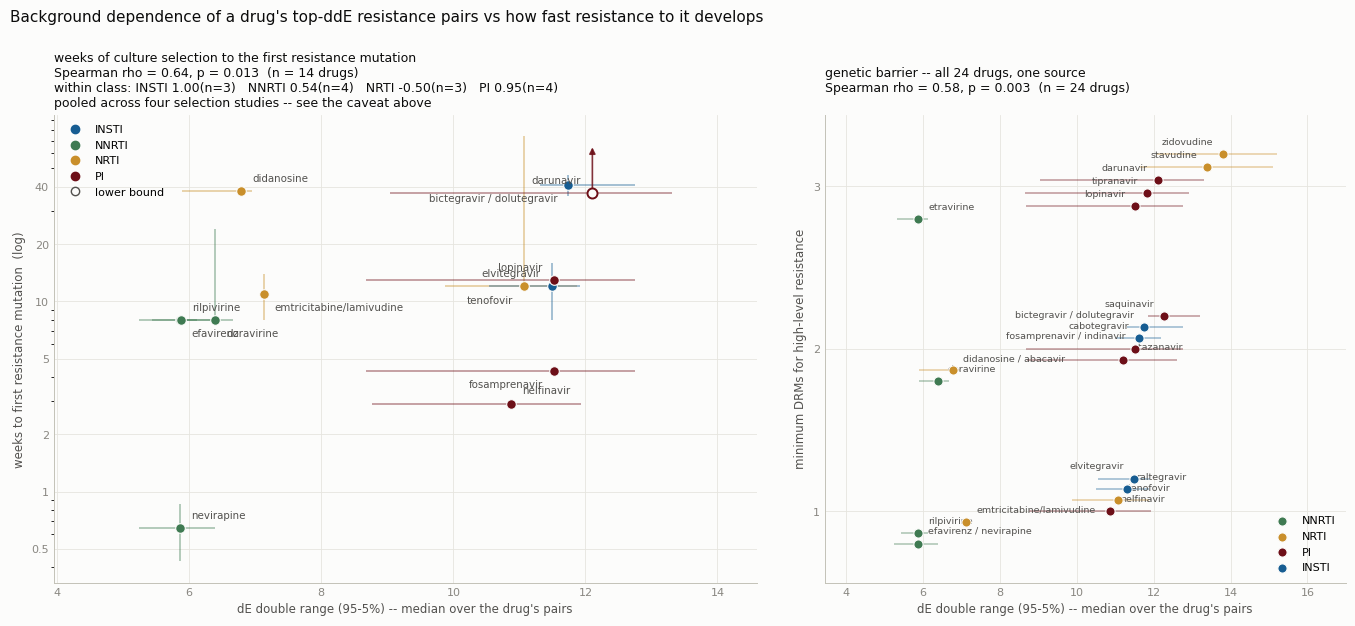

In [8]:
have_time = D['weeks_in_vitro'].notna() & D['x'].notna()
have_bar = D['barrier_mutations'].notna() & D['x'].notna()


def merge_ties(sub, ycol):
    """One marker per distinct (x, y): drugs that share a position list share a point.

    Labelling them separately draws the same name twice on top of itself. The joined label is
    also the honest one -- these are not independent measurements, they are one x with several
    drug names attached.
    """
    return (sub.assign(_x=sub['x'].round(2), _y=sub[ycol].round(2))
               .groupby(['_x', '_y', 'class'], as_index=False)
               .agg(x=('x', 'first'), y=(ycol, 'first'), q25=('q25', 'first'),
                    q75=('q75', 'first'),
                    cls=('class', 'first'),
                    label=('drug', ' / '.join), n=('n pairs', 'max'),
                    ylo=('weeks_in_vitro_low', 'first'), yhi=('weeks_in_vitro_high', 'first'),
                    cens=('censored', 'any')))


fig, axes = plt.subplots(1, 2, figsize=(13.6, 6.2), gridspec_kw={'width_ratios': [1.35, 1]})

# ---- LEFT: weeks to the first resistance mutation ----------------------------------------
# Log y: nevirapine sits at 0.6 weeks and darunavir past 37, and a linear axis spends its whole
# height on that gap and squashes everything else into a line.
ax = bare(axes[0])
sub = D[have_time]
g = merge_ties(sub, 'weeks_in_vitro')
for _, r in g.iterrows():
    col = CLASS_COLOR.get(r['cls'], MUTED)
    ax.plot([r['q25'], r['q75']], [r['y']] * 2, color=col, lw=1.2, alpha=.45,
            solid_capstyle='butt', zorder=1)
    if np.isfinite(r['ylo']) and np.isfinite(r['yhi']) and r['yhi'] > r['ylo']:
        ax.plot([r['x']] * 2, [r['ylo'], r['yhi']], color=col, lw=1.2, alpha=.45,
                solid_capstyle='butt', zorder=1)
    if r['cens']:                       # lower bound only -- arrow up, open marker
        ax.annotate('', xy=(r['x'], r['y'] * 1.8), xytext=(r['x'], r['y']),
                    arrowprops=dict(arrowstyle='-|>', color=col, lw=1.2, alpha=.85), zorder=2)
        ax.scatter(r['x'], r['y'], s=52, facecolor=SURFACE, edgecolor=col, linewidth=1.4,
                   zorder=3)
    else:
        ax.scatter(r['x'], r['y'], s=48, color=col, zorder=3, edgecolor=SURFACE, linewidth=.8)
    right = r['x'] > g['x'].median()
    up = _.__index__() % 2 == 0 if hasattr(_, '__index__') else True
    ax.annotate(r['label'], (r['x'], r['y']), xytext=(-8 if right else 8, 7 if up else -12),
                textcoords='offset points', ha='right' if right else 'left',
                fontsize=7.4, color=INK2)

ax.set_yscale('log')
ax.set_yticks([0.5, 1, 2, 5, 10, 20, 40])
ax.set_yticklabels(['0.5', '1', '2', '5', '10', '20', '40'])
rho, p, n = spearman(sub['x'].to_numpy(), sub['weeks_in_vitro'].to_numpy())
per_class = '   '.join(
    f"{cls} {spearman(gg['x'].to_numpy(), gg['weeks_in_vitro'].to_numpy())[0]:.2f}(n={len(gg)})"
    for cls, gg in sub.groupby('class') if len(gg) >= 3)
ax.set_title("weeks of culture selection to the first resistance mutation\n"
             f"Spearman rho = {rho:.2f}" + (f", p = {p:.3f}" if np.isfinite(p) else "")
             + f"  (n = {n} drugs)"
             + ("\nwithin class: " + per_class if per_class else "")
             + "\npooled across four selection studies -- see the caveat above",
             fontsize=9, color=INK, loc='left')
ax.margins(x=.16)
ax.set_xlabel(f"{RANGE_COL} -- median over the drug's pairs", fontsize=8.5, color=INK2)
ax.set_ylabel('weeks to first resistance mutation  (log)', fontsize=8.5, color=INK2)
ax.legend(handles=[plt.Line2D([], [], marker='o', ls='', color=CLASS_COLOR[k], label=k,
                              markersize=6) for k in sorted(sub['class'].unique())]
          + [plt.Line2D([], [], marker='o', ls='', mfc=SURFACE, mec=INK2, label='lower bound',
                        markersize=6)], fontsize=8, loc='upper left')

# ---- RIGHT: the genetic-barrier ordinal, every drug ---------------------------------------
ax = bare(axes[1])
g = merge_ties(D[have_bar], 'barrier_mutations').sort_values(['y', 'x']).reset_index(drop=True)
g['ypos'] = np.nan
for lev, block in g.groupby('y'):
    k = len(block)
    g.loc[block.index, 'ypos'] = lev + (np.linspace(-.20, .20, k) if k > 1 else np.array([0.0]))

seen = set()
for _, r in g.iterrows():
    col = CLASS_COLOR.get(r['cls'], MUTED)
    ax.plot([r['q25'], r['q75']], [r['ypos']] * 2, color=col, lw=1.2, alpha=.4,
            solid_capstyle='butt', zorder=1)
    ax.scatter(r['x'], r['ypos'], s=44, color=col, zorder=3, edgecolor=SURFACE, linewidth=.8,
               label=r['cls'] if r['cls'] not in seen else None)
    seen.add(r['cls'])
    right = r['x'] > g['x'].median()
    ax.annotate(r['label'], (r['x'], r['ypos']), xytext=(-7 if right else 7, 7),
                textcoords='offset points', ha='right' if right else 'left',
                fontsize=6.8, color=INK2)

rho, p, n = spearman(D.loc[have_bar, 'x'].to_numpy(),
                     D.loc[have_bar, 'barrier_mutations'].to_numpy())
ax.set_title("genetic barrier -- all 24 drugs, one source\n"
             f"Spearman rho = {rho:.2f}" + (f", p = {p:.3f}" if np.isfinite(p) else "")
             + f"  (n = {n} drugs)\n ",
             fontsize=9, color=INK, loc='left')
ax.set_yticks(sorted(D.loc[have_bar, 'barrier_mutations'].unique()))
ax.margins(x=.18, y=.10)
ax.set_xlabel(f"{RANGE_COL} -- median over the drug's pairs", fontsize=8.5, color=INK2)
ax.set_ylabel('minimum DRMs for high-level resistance', fontsize=8.5, color=INK2)
ax.legend(fontsize=8, loc='lower right')

fig.subplots_adjust(top=.82)
fig.suptitle("Background dependence of a drug's top-ddE resistance pairs "
             "vs how fast resistance to it develops",
             fontsize=11, color=INK, x=.008, ha='left', y=1.0)
fig.tight_layout(w_pad=3.0)
fig.savefig(out_dir / 'de_range_vs_resistance_time.pdf', bbox_inches='tight')
fig.savefig(out_dir / 'de_range_vs_resistance_time.png', dpi=220, bbox_inches='tight')
plt.show()

## Sensitivity — does the answer depend on the choices?

Four of them: the percentile cut that defines "range", median vs mean over a drug's pairs, the
`either` / `both` attribution rule, and pooling classes. Each is re-run against the barrier
ordinal; a ρ that moves a lot between rows is a ρ that was reading the choice, not the data.

One caveat the ρ cannot show on its own: several drugs share an IAS-USA position list almost
exactly, so they are attributed the same pairs and land on the same x. fosamprenavir / indinavir /
lopinavir, efavirenz / nevirapine and didanosine / abacavir are ties by construction, not three
independent measurements each. The tie groups are printed below — the effective number of distinct
x values is smaller than the 24 drugs plotted.


In [9]:
def drug_x(P_rule, range_col, stat):
    """Per-drug x under one (attribution rule, range column, statistic) combination."""
    vals = {}
    for P in PROTEINS:
        for d in DRUG_ORDER[P]:
            if d in NOT_A_DRUG:
                continue
            v = drug_pairs(P, d, P_rule)[range_col].to_numpy()
            vals[(P, d)] = (np.median(v) if stat == 'median' else v.mean()) if len(v) else np.nan
    return pd.Series(vals)


SENS = []
for rule in ('either', 'both'):
    for col in ('dE double range (95-5%)', 'dE double range (90-10%)',
                'dE double range (max-min)'):
        for stat in ('median', 'mean'):
            x = drug_x(rule, col, stat)
            key = list(zip(D['protein'], D['drug']))
            xv = np.array([x.get(k, np.nan) for k in key])
            rb, pb, nb_ = spearman(xv, D['barrier_mutations'].to_numpy())
            rw, pw, nw = spearman(xv, D['weeks_in_vitro'].to_numpy())
            SENS.append({'attribution': rule, 'range column': col, 'statistic': stat,
                         'rho vs weeks': rw, 'p (weeks)': pw, 'drugs (weeks)': nw,
                         'rho vs barrier': rb, 'p (barrier)': pb, 'drugs (barrier)': nb_})

SENS = pd.DataFrame(SENS)
display(SENS.round(3))

# and the per-class breakdown of the headline row
head = D[have_bar]
print('\nper class, ATTRIBUTION =', ATTRIBUTION, '/', RANGE_COL, '/ median:')
for cls, g in head.groupby('class'):
    rb = spearman(g['x'].to_numpy(), g['barrier_mutations'].to_numpy())
    rw = spearman(g['x'].to_numpy(), g['weeks_in_vitro'].to_numpy())
    print(f"  {cls:<6} rho vs weeks = {rw[0]:6.3f} (n={rw[2]})   "
          f"rho vs barrier = {rb[0]:6.3f} (n={rb[2]})   "
          f"x range {g['x'].min():.1f}-{g['x'].max():.1f}")

# drugs that are ties by construction -- same attributed pairs, therefore the same x
print('\ntie groups (identical attributed pair sets):')
ties = D.groupby(['protein', 'pairs listed'])['drug'].apply(list)
for g in ties:
    if len(g) > 1:
        print('  ', ', '.join(g))
print(f"  {D['x'].round(6).nunique()} distinct x values among {len(D)} drugs")


,attribution,range column,statistic,rho vs weeks,p (weeks),drugs (weeks),rho vs barrier,p (barrier),drugs (barrier)
0,either,dE double range (95-5%),median,0.644,0.013,14,0.582,0.003,24
1,either,dE double range (95-5%),mean,0.673,0.008,14,0.386,0.062,24
2,either,dE double range (90-10%),median,0.360,0.207,14,0.588,0.003,24
3,either,dE double range (90-10%),mean,0.673,0.008,14,0.354,0.089,24
4,either,dE double range (max-min),median,0.599,0.024,14,0.240,0.259,24
5,either,dE double range (max-min),mean,0.582,0.029,14,0.220,0.303,24
6,both,dE double range (95-5%),median,0.613,0.059,10,0.382,0.096,20
7,both,dE double range (95-5%),mean,0.651,0.041,10,0.308,0.186,20
8,both,dE double range (90-10%),median,0.409,0.241,10,0.517,0.020,20
9,both,dE double range (90-10%),mean,0.651,0.041,10,0.308,0.186,20



per class, ATTRIBUTION = either / dE double range (95-5%) / median:
  INSTI  rho vs weeks =  1.000 (n=3)   rho vs barrier =  0.889 (n=5)   x range 11.3-11.7
  NNRTI  rho vs weeks =  0.544 (n=4)   rho vs barrier =  0.648 (n=5)   x range 5.9-6.4
  NRTI   rho vs weeks = -0.500 (n=3)   rho vs barrier =  0.485 (n=6)   x range 6.8-13.8
  PI     rho vs weeks =  0.949 (n=4)   rho vs barrier =  0.561 (n=8)   x range 10.9-12.3

tie groups (identical attributed pair sets):
   bictegravir, dolutegravir
   fosamprenavir, indinavir, lopinavir
   didanosine, abacavir
   efavirenz, nevirapine
  18 distinct x values among 24 drugs


## Out

`de_range_vs_resistance_time.csv` is the plotted table — one row per drug, both x variants, both
y columns, the pairs each drug was attributed and the literature source string — so the figure
can be redrawn or the numbers quoted without re-running the alignment work.

In [10]:
OUT = D[['protein', 'drug', 'class', 'n pairs', 'x', 'q25', 'q75',
         'median range (either)', 'median range (both)', 'mean range (either)',
         'pairs (either)', 'pairs (both)',
         'barrier_mutations', 'weeks_in_vitro', 'weeks_in_vitro_low', 'weeks_in_vitro_high', 'censored',
         'source', 'confidence', 'note', 'pairs listed']].copy()
OUT = OUT.rename(columns={'x': f'x = median {RANGE_COL} ({ATTRIBUTION})'})
OUT.to_csv(out_dir / 'de_range_vs_resistance_time.csv', index=False)
PAIR_TABLE.to_csv(out_dir / 'de_range_per_pair_all_proteins.csv', index=False)
print('wrote de_range_vs_resistance_time.csv and de_range_per_pair_all_proteins.csv')
OUT.head(10).round(2)

wrote de_range_vs_resistance_time.csv and de_range_per_pair_all_proteins.csv


,protein,drug,class,n pairs,x = median dE double range (95-5%) (either),q25,q75,median range (either),median range (both),mean range (either),...,pairs (both),barrier_mutations,weeks_in_vitro,weeks_in_vitro_low,weeks_in_vitro_high,censored,source,confidence,note,pairs listed
0,IN,bictegravir,INSTI,12,11.74,11.31,12.76,11.74,11.88,12.32,...,9,2,41.0,36.0,46.0,False,Oliveira 2018 Retrovirology PMC6098636,medium,solitary low-level (<3-fold) mutation at wk 36...,"G140S-Q148H, G140A-Q148K, G140S-Q148R, G140A-Q..."
1,IN,cabotegravir,INSTI,15,11.61,11.01,12.20,11.61,11.88,12.05,...,9,2,NaN,NaN,NaN,False,Oliveira 2018 Retrovirology PMC6098636,low,resistance in 8/12 isolates over the 36-46 wk ...,"G140S-Q148H, G140A-Q148K, G140S-Q148R, G140A-Q..."
2,IN,dolutegravir,INSTI,12,11.74,11.31,12.76,11.74,11.88,12.32,...,11,2,41.0,36.0,46.0,False,Oliveira 2018 Retrovirology PMC6098636,medium,solitary low-level (<3-fold) mutation at wk 36-46,"G140S-Q148H, G140A-Q148K, G140S-Q148R, G140A-Q..."
3,IN,elvitegravir,INSTI,17,11.49,10.54,11.92,11.49,11.88,11.82,...,11,1,12.0,8.0,16.0,False,Oliveira 2018 Retrovirology PMC6098636,high,primary mutation (T66I/A E92G/V/Q T97A R263K) ...,"G140S-Q148H, G140A-Q148K, G140S-Q148R, G140A-Q..."
4,IN,raltegravir,INSTI,20,11.30,10.51,11.89,11.30,11.69,11.66,...,12,1,NaN,NaN,NaN,False,IAS-USA 2025,low,not in the Oliveira passage panel - FILL IN,"G140S-Q148H, Y143C-S230R, G140A-Q148K, G140S-Q..."
5,PR,atazanavir,PI,19,11.20,8.71,12.60,11.20,11.86,10.75,...,11,2,NaN,NaN,NaN,False,IAS-USA 2025 / Stanford HIVDB,low,FILL IN,"D30N-N88D, V32I-I47V, G48V-I54A, I54A-V82A, I5..."
6,PR,darunavir,PI,10,12.11,9.04,13.30,12.11,7.33,11.34,...,1,3,37.1,37.1,NaN,True,De Meyer 2008 Antivir Chem Chemother PMC2699666,high,"no breakthrough virus at 260 days - censored, ...","V32I-I47V, G48V-I54A, I54A-V82A, I54V-V82A, M4..."
7,PR,fosamprenavir,PI,18,11.52,8.68,12.76,11.52,11.52,10.83,...,8,2,4.3,4.3,4.3,False,De Meyer 2008 Antivir Chem Chemother PMC2699666,medium,breakthrough at 30 days under high drug concen...,"V32I-I47V, G48V-I54A, I54A-V82A, I54V-V82A, M4..."
8,PR,indinavir,PI,18,11.52,8.68,12.76,11.52,11.89,10.83,...,8,2,NaN,NaN,NaN,False,IAS-USA 2025 / Stanford HIVDB,low,FILL IN,"V32I-I47V, G48V-I54A, I54A-V82A, I54V-V82A, M4..."
9,PR,lopinavir,PI,18,11.52,8.68,12.76,11.52,11.52,10.83,...,10,3,12.9,12.9,12.9,False,De Meyer 2008 Antivir Chem Chemother PMC2699666,high,breakthrough at 90 days under high drug concen...,"V32I-I47V, G48V-I54A, I54A-V82A, I54V-V82A, M4..."
